# 05. Robustness: kontroliuojamas Gauso triukšmas TEST duomenyse

Šiame etape **nedarome** naujo GridSearch, naujo skaidymo, abliacijos kartojimo, missing-data bandymo ir SOM.

Tikslas — patikrinti, kaip jau apmokytų k-NN, SVM ir MLP kokybė keičiasi, kai **vertinimo metu** TEST požymiams pridedamas kontroliuojamas Gauso triukšmas.

**Eksperimento logika.** TRAIN paliekamas švarus. Modeliai mokomi tik su švariu TRAIN. Triukšmas pridedamas tik TEST, kad imituotume eksploataciją su triukšmingesniais požymiais.

Hiperparametrai fiksuoti iš 2–3 etapų TRAIN CV: k-NN `n_neighbors=11`, `weights=distance`; SVM `C=0.01`; MLP `hidden_layer_sizes=(100,)`, `alpha=0.001`, `random_state=42`, `max_iter=500`.

## Kas čia yra ir ko čia nėra

Kad skirtingo mastelio UCI HAR požymiams triukšmo dydis būtų palyginamas, Gauso triukšmas pridedamas **standartizuotoje** požymių erdvėje.

`StandardScaler` mokomas **tik** iš TRAIN. Po to kiekvienas požymis TRAIN dalyje turi vidurkį 0 ir dispersiją 1, todėl `sigma=0.1` reiškia triukšmo standartinį nuokrypį, lygų apie **0.1 standartizuoto požymio vieneto**.

Tai **kontroliuojamas požymių erdvės robustness testas**, o ne tikslus telefono IMU / akselerometro / giroskopo fizikinis triukšmo modelis. Realus sensoriaus triukšmas gali turėti kitokią struktūrą, koreliaciją, bias, drift ir laiko priklausomybę.

**Kodėl scaleris ne Pipeline viduje.** Triukšmą reikia pridėti **po** standartizavimo ir **prieš** `predict`. Jei scaler būtų Pipeline viduje, `predict(X_test_noisy_raw)` vėl transformuotų jau sugadintus raw požymius, ir `sigma` nebebūtų vienodo masto visiems požymiams. Čia scaler `fit` daromas vieną kartą su švariu TRAIN, o modeliai gauna jau skalę `X_train_scaled` / `X_test_scaled` (+ triukšmas tik TEST).

In [1]:
from pathlib import Path
import hashlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
SIGMAS = [0.0, 0.1, 0.2, 0.3, 0.5]
np.random.seed(RANDOM_STATE)
rng = np.random.default_rng(RANDOM_STATE)

print(f"RANDOM_STATE = {RANDOM_STATE}")
print("sigma lygiai:", SIGMAS)

RANDOM_STATE = 42
sigma lygiai: [0.0, 0.1, 0.2, 0.3, 0.5]


## TRAIN/TEST užkrovimas

Naudojamas tik 1 etapo `results/subject_disjoint_split.npz`. Naujo skaidymo nekuriame.

In [2]:
cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
project_root = None
for cand in candidates:
    if (cand / "results").exists() and (cand / "notebooks").exists():
        project_root = cand
        break
if project_root is None:
    project_root = cwd.parent if cwd.name == "notebooks" else cwd

results_dir = project_root / "results"
split_path = results_dir / "subject_disjoint_split.npz"
baseline_path = results_dir / "baseline_results.csv"
intel_path = results_dir / "intelligent_models_results.csv"

split = np.load(split_path, allow_pickle=True)
X_train = split["X_train_final"]
X_test = split["X_test_final"]
y_train = split["y_train_final"]
y_test = split["y_test_final"]
subjects_train = split["subjects_train_final"]
subjects_test = split["subjects_test_final"]
overlap = sorted(set(subjects_train.tolist()) & set(subjects_test.tolist()))

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("Požymių skaičius:", X_train.shape[1])
print("TRAIN subject:", len(np.unique(subjects_train)), "TEST subject:", len(np.unique(subjects_test)))
print("TRAIN ∩ TEST subject:", overlap)
assert X_train.shape == (7144, 561)
assert X_test.shape == (3155, 561)
assert overlap == []
print("Patikra: dydžiai ir tuščia subject sankirta OK.")

X_train: (7144, 561) X_test: (3155, 561)
Požymių skaičius: 561
TRAIN subject: 21 TEST subject: 9
TRAIN ∩ TEST subject: []
Patikra: dydžiai ir tuščia subject sankirta OK.


## Viena standartizuota erdvė visiems modeliams

`StandardScaler.fit` tik ant `X_train`. Tada ta pati transformacija TRAIN ir TEST. Ši skalė naudojama visiems trims modeliams, todėl tam pačiam `sigma` jie gauna **identišką** `X_test_noisy`.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("TRAIN scaled mean (pirmi 3 požymiai):", X_train_scaled.mean(axis=0)[:3])
print("TRAIN scaled std  (pirmi 3 požymiai):", X_train_scaled.std(axis=0)[:3])
print("Scaler fit darytas tik su švariu TRAIN. TEST scaler.fit nenaudotas.")

noisy_test = {}
noise_hashes = {}
for sigma in SIGMAS:
    if sigma == 0.0:
        epsilon = np.zeros_like(X_test_scaled)
    else:
        epsilon = rng.normal(loc=0.0, scale=sigma, size=X_test_scaled.shape)
    X_noisy = X_test_scaled + epsilon
    noisy_test[sigma] = X_noisy
    noise_hashes[sigma] = hashlib.sha256(np.ascontiguousarray(X_noisy).tobytes()).hexdigest()[:16]
    print(
        f"sigma={sigma:.1f}: epsilon std={epsilon.std():.6f}, "
        f"X_test_noisy hash={noise_hashes[sigma]}"
    )

assert np.array_equal(noisy_test[0.0], X_test_scaled)
print("Patikra: sigma=0 noisy TEST sutampa su švariu X_test_scaled.")

TRAIN scaled mean (pirmi 3 požymiai): [-1.13881779e-16 -2.88434201e-17  1.05924974e-16]


TRAIN scaled std  (pirmi 3 požymiai): [1. 1. 1.]
Scaler fit darytas tik su švariu TRAIN. TEST scaler.fit nenaudotas.
sigma=0.0: epsilon std=0.000000, X_test_noisy hash=108420377c01e982
sigma=0.1: epsilon std=0.100012, X_test_noisy hash=2f84475d3a0e7080


sigma=0.2: epsilon std=0.199903, X_test_noisy hash=8f6c2bf217a701b5
sigma=0.3: epsilon std=0.299909, X_test_noisy hash=43ab22d7bc0510b2


sigma=0.5: epsilon std=0.499884, X_test_noisy hash=b02da84b49f06943
Patikra: sigma=0 noisy TEST sutampa su švariu X_test_scaled.


## Modeliai mokomi su švariu TRAIN

Papildomo `StandardScaler` modelio viduje nėra — įėjimas jau `X_train_scaled`. LinearSVC ir MLP nuostatos tokios pat kaip 03/04 etapuose.

In [4]:
caught_warnings = []
models = {
    "k-NN": KNeighborsClassifier(n_neighbors=11, weights="distance"),
    "SVM": LinearSVC(
        C=0.01,
        random_state=RANDOM_STATE,
        max_iter=10000,
        dual="auto",
    ),
    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,),
        alpha=0.001,
        random_state=RANDOM_STATE,
        max_iter=500,
    ),
}

for name, model in models.items():
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model.fit(X_train_scaled, y_train)
        unique = []
        for item in caught:
            msg = f"{item.category.__name__}: {item.message}"
            caught_warnings.append({"etapas": f"fit {name}", "pranesimas": msg})
            if msg not in unique:
                unique.append(msg)
                print(f"[fit {name}] {msg}")
        if not unique:
            print(f"[fit {name}] Warning nebuvo.")
print("Visi modeliai apmokyti tik su švariu X_train_scaled.")

[fit k-NN] Warning nebuvo.


[fit SVM] Warning nebuvo.


[fit MLP] Warning nebuvo.
Visi modeliai apmokyti tik su švariu X_train_scaled.


## 15 įvertinimų: 3 modeliai × 5 sigma

Kiekvienam `sigma` visų modelių `predict` kviečiamas su **ta pačia** `noisy_test[sigma]` matrica. TRAIN nekeičiamas.

In [5]:
rows = []
used_hashes = []

for name, model in models.items():
    for sigma in SIGMAS:
        X_eval = noisy_test[sigma]
        used_hashes.append(
            {
                "Model": name,
                "Noise Sigma": sigma,
                "X_test_noisy hash": hashlib.sha256(
                    np.ascontiguousarray(X_eval).tobytes()
                ).hexdigest()[:16],
            }
        )
        y_pred = model.predict(X_eval)
        rows.append(
            {
                "Model": name,
                "Noise Sigma": sigma,
                "Macro-F1": float(f1_score(y_test, y_pred, average="macro")),
                "Balanced Accuracy": float(balanced_accuracy_score(y_test, y_pred)),
            }
        )

results = pd.DataFrame(rows)
base_f1 = results.loc[results["Noise Sigma"] == 0.0, ["Model", "Macro-F1"]].rename(
    columns={"Macro-F1": "F1_sigma0"}
)
results = results.merge(base_f1, on="Model", how="left")
results["Delta Macro-F1 vs sigma=0"] = results["Macro-F1"] - results["F1_sigma0"]
results = results.drop(columns=["F1_sigma0"])

hash_df = pd.DataFrame(used_hashes)
print("Identiškas noisy TEST pagal sigma (visi modeliai turi tą patį hash):")
for sigma in SIGMAS:
    hashes = hash_df.loc[hash_df["Noise Sigma"] == sigma, "X_test_noisy hash"].unique()
    print(f"  sigma={sigma:.1f}: unique hashes={len(hashes)} -> {hashes[0]}")
    assert len(hashes) == 1

print()
print(results.to_string(index=False))

Identiškas noisy TEST pagal sigma (visi modeliai turi tą patį hash):
  sigma=0.0: unique hashes=1 -> 108420377c01e982
  sigma=0.1: unique hashes=1 -> 2f84475d3a0e7080
  sigma=0.2: unique hashes=1 -> 8f6c2bf217a701b5
  sigma=0.3: unique hashes=1 -> 43ab22d7bc0510b2
  sigma=0.5: unique hashes=1 -> b02da84b49f06943

Model  Noise Sigma  Macro-F1  Balanced Accuracy  Delta Macro-F1 vs sigma=0
 k-NN          0.0  0.844324           0.842074                   0.000000
 k-NN          0.1  0.844294           0.842156                  -0.000029
 k-NN          0.2  0.849383           0.847187                   0.005059
 k-NN          0.3  0.844879           0.842720                   0.000556
 k-NN          0.5  0.841872           0.839668                  -0.002451
  SVM          0.0  0.897130           0.893666                   0.000000
  SVM          0.1  0.897725           0.894106                   0.000595
  SVM          0.2  0.888484           0.884236                  -0.008645
  SVM     

## Kontrolinis palyginimas: sigma=0 vs 2/3 etapų All-features

`sigma=0` perskaičiuojamas čia ir lyginamas su `baseline_results.csv` bei `intelligent_models_results.csv`. Skirtumo neslepiame; modelio pagal TEST nekeičiame.

In [6]:
prev = pd.concat(
    [pd.read_csv(baseline_path), pd.read_csv(intel_path)],
    ignore_index=True,
)
prev = prev[prev["Model"].isin(["k-NN", "SVM", "MLP"])].set_index("Model")
now0 = results[results["Noise Sigma"] == 0.0].set_index("Model")

print("Ankstesni All-features TEST:")
print(prev.to_string())
print()
print("Šio etapo sigma=0:")
print(now0[["Macro-F1", "Balanced Accuracy"]].to_string())
print()

for model in ["k-NN", "SVM", "MLP"]:
    f1_ok = np.isclose(
        now0.loc[model, "Macro-F1"], prev.loc[model, "Macro-F1"], rtol=0.0, atol=1e-12
    )
    ba_ok = np.isclose(
        now0.loc[model, "Balanced Accuracy"],
        prev.loc[model, "Balanced Accuracy"],
        rtol=0.0,
        atol=1e-12,
    )
    d_f1 = now0.loc[model, "Macro-F1"] - prev.loc[model, "Macro-F1"]
    d_ba = now0.loc[model, "Balanced Accuracy"] - prev.loc[model, "Balanced Accuracy"]
    status = "SUTAMPA" if (f1_ok and ba_ok) else "NESUTAMPA"
    print(f"{model} sigma=0 vs ankstesnis: {status} (dF1={d_f1:.3e}, dBA={d_ba:.3e})")

Ankstesni All-features TEST:
       Macro-F1  Balanced Accuracy
Model                             
k-NN   0.844324           0.842074
SVM    0.897130           0.893666
MLP    0.896616           0.894957

Šio etapo sigma=0:
       Macro-F1  Balanced Accuracy
Model                             
k-NN   0.844324           0.842074
SVM    0.897130           0.893666
MLP    0.896616           0.894957

k-NN sigma=0 vs ankstesnis: SUTAMPA (dF1=0.000e+00, dBA=0.000e+00)
SVM sigma=0 vs ankstesnis: SUTAMPA (dF1=0.000e+00, dBA=0.000e+00)
MLP sigma=0 vs ankstesnis: SUTAMPA (dF1=0.000e+00, dBA=0.000e+00)


## Kritimas nuo sigma=0 iki sigma=0.5

Čia tik objektyvus šio testo rodiklis, **ne** galutinis modelio pasirinkimas.

In [7]:
drop_rows = []
for model in ["k-NN", "SVM", "MLP"]:
    f1_0 = results.loc[
        (results["Model"] == model) & (results["Noise Sigma"] == 0.0), "Macro-F1"
    ].iloc[0]
    f1_5 = results.loc[
        (results["Model"] == model) & (results["Noise Sigma"] == 0.5), "Macro-F1"
    ].iloc[0]
    drop_rows.append(
        {
            "Model": model,
            "Macro-F1 sigma=0": f1_0,
            "Macro-F1 sigma=0.5": f1_5,
            "Drop Macro-F1 (0 -> 0.5)": f1_0 - f1_5,
        }
    )
drop_table = pd.DataFrame(drop_rows)
print(drop_table.to_string(index=False))
max_drop = drop_table.loc[drop_table["Drop Macro-F1 (0 -> 0.5)"].idxmax(), "Model"]
min_drop = drop_table.loc[drop_table["Drop Macro-F1 (0 -> 0.5)"].idxmin(), "Model"]
print()
print(f"Šiame teste daugiausiai Macro-F1 prarado: {max_drop}")
print(f"Šiame teste mažiausiai Macro-F1 prarado: {min_drop}")
print("Šiame teste modelių jautrumas triukšmui skyrėsi.")

Model  Macro-F1 sigma=0  Macro-F1 sigma=0.5  Drop Macro-F1 (0 -> 0.5)
 k-NN          0.844324            0.841872                  0.002451
  SVM          0.897130            0.859410                  0.037720
  MLP          0.896616            0.878703                  0.017913

Šiame teste daugiausiai Macro-F1 prarado: SVM
Šiame teste mažiausiai Macro-F1 prarado: k-NN
Jautrumas skyrėsi:


## Robustness grafikas

x — Noise Sigma, y — TEST Macro-F1, atskiros kreivės k-NN, SVM ir MLP.

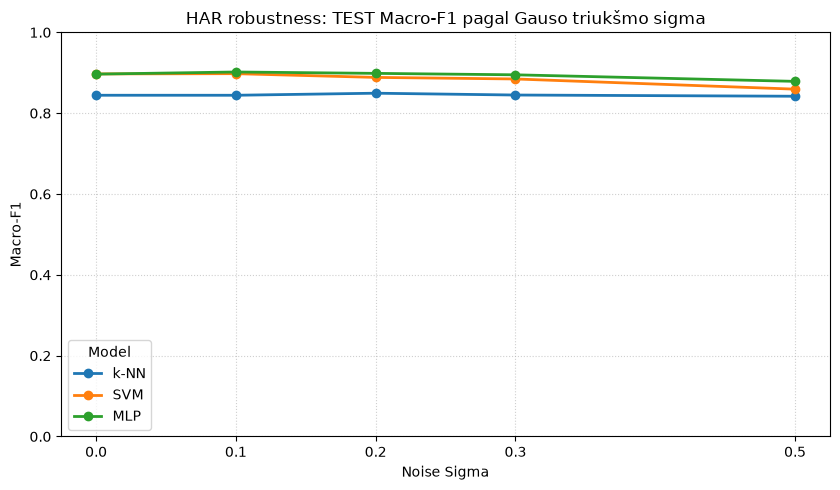

Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\noise_robustness_macro_f1.svg
Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\noise_robustness_macro_f1.png


In [8]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
for model in ["k-NN", "SVM", "MLP"]:
    sub = results[results["Model"] == model].sort_values("Noise Sigma")
    ax.plot(
        sub["Noise Sigma"],
        sub["Macro-F1"],
        marker="o",
        linewidth=2,
        label=model,
    )
ax.set_xlabel("Noise Sigma")
ax.set_ylabel("Macro-F1")
ax.set_title("HAR robustness: TEST Macro-F1 pagal Gauso triukšmo sigma")
ax.set_xticks(SIGMAS)
ax.set_ylim(0.0, 1.0)
ax.grid(True, linestyle=":", alpha=0.6)
ax.legend(title="Model")
fig.tight_layout()

svg_path = results_dir / "noise_robustness_macro_f1.svg"
png_path = results_dir / "noise_robustness_macro_f1.png"
fig.savefig(svg_path, format="svg")
fig.savefig(png_path, format="png", dpi=200)
plt.show()
print(f"Išsaugota: {svg_path}")
print(f"Išsaugota: {png_path}")

## Interpretacija

Žemiau **faktas** ir **hipotezė** atskirti. Skaičiai — šio notebook TEST rezultatai.

**Faktai.** `sigma=0` visiems trims modeliams sutapo su 2/3 etapų All-features TEST. Tarp `sigma=0` ir `sigma=0.5` Macro-F1 krito: k-NN nuo 0.844324 iki 0.841872 (Δ = −0.002451); SVM nuo 0.897130 iki 0.859410 (Δ = −0.037720); MLP nuo 0.896616 iki 0.878703 (Δ = −0.017913). Šiame teste daugiausiai Macro-F1 prarado SVM, mažiausiai — k-NN. Modelių jautrumas skyrėsi. Tarpiniuose lygiuose k-NN Macro-F1 ties `sigma=0.2` buvo 0.849383 (šiek tiek aukščiau nei `sigma=0`); MLP ties `sigma=0.1` buvo 0.901872 (taip pat šiek tiek aukščiau nei `sigma=0`); SVM nuo `sigma=0.2` nuosekliai blogėjo.

**Hipotezė (neįrodyta).** Galimas paaiškinimas, kad izotropinis Gauso triukšmas standartizuotoje erdvėje k-NN balsavimą keičia silpniau nei linijinio SVM sprendimo ribas, bet šis eksperimentas to mechanizmo neįrodo — matome tik metrikų pokytį.

**Eksperimento riba.** Tai sintetinis Gaussian noise standartizuotoje 561 požymių erdvėje (`epsilon ~ N(0, sigma^2)` po `StandardScaler`). Tai nėra konkretaus IMU gedimo, bias, drift ar laike koreliuoto sensoriaus triukšmo modelis. Realus telefono jutiklių triukšmas gali turėti kitokią struktūrą, todėl šio testo negalima tiesiogiai perkelti į fizinę IMU gedimo išvadą.

Tai dar nėra galutinis modelio pasirinkimas visam projektui.

## Rezultatų išsaugojimas

Ankstesnių etapų CSV ir `subject_disjoint_split.npz` neperrašomi.

In [9]:
out_csv = results_dir / "noise_robustness_results.csv"
results.to_csv(out_csv, index=False)
print(f"Išsaugota: {out_csv}")
print("Ankstesni rezultatai ir split nekeisti.")
if caught_warnings:
    print(pd.DataFrame(caught_warnings).drop_duplicates().to_string(index=False))
else:
    print("Warning šiame paleidime nebuvo užfiksuota.")
print("5 etapas baigtas.")

Išsaugota: C:\Users\Lenovo\Desktop\Studijos 2026\Magistras\Intelektualios sistemos\Egzaminas\EGZ_Dovaldas_Dovidovic_EKSFM-26\results\noise_robustness_results.csv
Ankstesni rezultatai ir split nekeisti.
Warning šiame paleidime nebuvo užfiksuota.
5 etapas baigtas.
